<a href="https://colab.research.google.com/github/Giraffe-Shin/trading/blob/main/Basic/Basic_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from google.colab import userdata

# 기존 설정 재사용
try:
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main' # 이 부분은 contents API에서는 직접적으로 사용되지 않지만, 다른 작업 시 필요할 수 있습니다.
directory_path = 'data'

# GitHub API를 사용하여 디렉토리 내용 가져오기
api_url = f'https://api.github.com/repos/{username}/{repo}/contents/{directory_path}'

headers = {
    'Authorization': f'token {github_token}',
    'Accept': 'application/vnd.github.v3+json' # GitHub API 버전 3 사용 명시
}

try:
    response = requests.get(api_url, headers=headers)

    if response.status_code == 200:
        contents = response.json()
        file_names = [item['name'] for item in contents if item['type'] == 'file']
        print(f"'{directory_path}' 디렉토리의 파일 목록:")
        for file_name in file_names:
            print(f"- {file_name}")
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다. GitHub 토큰을 확인해주세요.")
    elif response.status_code == 404:
        print(f"디렉토리 '{directory_path}'를 찾을 수 없습니다. 경로를 확인해주세요.")
    else:
        print(f"파일 목록을 가져오는 데 실패했습니다. 상태 코드: {response.status_code}, 메시지: {response.text}")
except Exception as e:
    print(f"오류 발생: {e}")


'data' 디렉토리의 파일 목록:
- germany_actual_generation.csv
- germany_cbet_trading.csv
- germany_cbpf_physical_flow.csv
- germany_energy_master.csv
- germany_forecast_day_ahead.csv
- germany_market_prices.csv
- germany_renewable_share_daily.csv


In [38]:
import pandas as pd
import requests
from io import StringIO
from google.colab import userdata

# --- 필수 설정 ---
try:
    # Colab 보안 비밀(Secrets)에서 토큰을 가져옵니다.
    github_token = userdata.get('GITHUB_TOKEN')
except Exception:
    github_token = 'YOUR_TOKEN_HERE'

username = 'Giraffe-Shin'
repo = 'trading'
branch = 'main'
file_path = 'data/germany_actual_generation.csv'

# API를 통한 프라이빗 파일 접근 URL
url = f'https://raw.githubusercontent.com/{username}/{repo}/{branch}/{file_path}'

headers = {'Authorization': f'token {github_token}'}

try:
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        df = pd.read_csv(StringIO(response.text))
        print("성공적으로 파일을 불러왔습니다!")
        display(df.head())
    elif response.status_code == 401:
        print("인증 실패: 토큰이 유효하지 않거나 권한이 없습니다.")
    elif response.status_code == 404:
        print("파일을 찾을 수 없습니다(404). 토큰 이름, 경로, 브랜치명을 다시 확인해주세요.")
    else:
        print(f"실패했습니다. 상태 코드: {response.status_code}")
except Exception as e:
    print(f"오류 발생: {e}")

성공적으로 파일을 불러왔습니다!


,timestamp,Hydro pumped storage consumption,Cross border electricity trading,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,...,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Load,Residual load,Renewable share of load,Renewable share of generation
0,2022-12-31 23:00:00,-1975.8,-12645.2,2460.7,1627.7,4022.8,3845.6,1825.5,306.0,670.0,...,127.0,187.4,1050.3,2739.0,27260.9,0.0,38691.8,8691.8,93.7,75.5
1,2022-12-31 23:15:00,-2009.5,-12544.0,2458.5,1624.8,4012.0,3847.7,1828.6,306.8,648.2,...,180.1,187.3,1049.1,2975.6,27311.5,0.0,38374.2,8087.1,95.1,75.7
2,2022-12-31 23:30:00,-2244.0,-12526.2,2459.6,1624.8,4010.0,3860.2,1825.2,306.9,648.2,...,106.9,187.2,1055.2,3269.6,27699.4,0.0,38248.0,7279.0,97.2,76.0
3,2022-12-31 23:45:00,-2077.3,-12515.4,2457.9,1622.0,4004.0,3861.6,1819.7,306.0,639.1,...,87.0,187.3,1043.6,3259.5,27170.0,0.0,38070.2,7640.6,96.3,75.8
4,2023-01-01 00:00:00,-1204.1,-15410.1,2457.7,1622.3,3988.4,3869.8,1811.4,306.0,635.0,...,547.7,187.3,1047.1,3144.1,27853.6,0.0,37733.4,6735.7,98.5,76.3


In [43]:
# 데이터프레임의 컬럼 이름 리스트 출력
column_list = df.columns.tolist()
print(column_list)

['timestamp', 'Hydro pumped storage consumption', 'Cross border electricity trading', 'Nuclear', 'Hydro Run-of-River', 'Biomass', 'Fossil brown coal / lignite', 'Fossil hard coal', 'Fossil oil', 'Fossil coal-derived gas', 'Fossil gas', 'Geothermal', 'Hydro water reservoir', 'Hydro pumped storage', 'Others', 'Waste', 'Wind offshore', 'Wind onshore', 'Solar', 'Load', 'Residual load', 'Renewable share of load', 'Renewable share of generation']


In [68]:
df_time = df.copy()
# timestamp 컬럼을 datetime 형식으로 변환
df_time['timestamp'] = pd.to_datetime(df_time['timestamp'])

# timestamp를 인덱스로 설정
df_time.set_index('timestamp', inplace=True)

# 15분 값으로 변환
df_time = df_time * (15/60)



# 제외할 컬럼 리스트
cols_to_exclude = [
    "Load",
    "Residual load",
    "Renewable share of generation",
    "Renewable share of load",
    "Cross border electricity trading"
]

# 해당 컬럼들을 제외하고 데이터프레임 업데이트 -> prod_df 만들었음
prod_df = df_time.drop(columns=cols_to_exclude)

# 'timestamp'를 제외한 모든 수치형 열의 합계를 구하여 새로운 'Total' 열 생성
prod_df['Total'] = prod_df.sum(axis=1)

# 결과 확인
display(prod_df)

,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31 23:00:00,-493.950,615.175,406.925,1005.700,961.400,456.375,76.500,167.500,470.500,4.550,18.275,31.750,46.850,262.575,684.750,6815.225,0.00,11530.100
2022-12-31 23:15:00,-502.375,614.625,406.200,1003.000,961.925,457.150,76.700,162.050,470.225,4.625,16.475,45.025,46.825,262.275,743.900,6827.875,0.00,11596.500
2022-12-31 23:30:00,-561.000,614.900,406.200,1002.500,965.050,456.300,76.725,162.050,473.300,4.675,16.350,26.725,46.800,263.800,817.400,6924.850,0.00,11696.625
2022-12-31 23:45:00,-519.325,614.475,405.500,1001.000,965.400,454.925,76.500,159.775,471.475,4.650,20.900,21.750,46.825,260.900,814.875,6792.500,0.00,11592.125
2023-01-01 00:00:00,-301.025,614.425,405.575,997.100,967.450,452.850,76.500,158.750,424.100,4.650,14.325,136.925,46.825,261.775,786.025,6963.400,0.00,12009.650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-10 11:30:00,-1115.450,NaN,572.075,911.725,1208.200,485.175,94.025,96.225,854.400,3.400,6.350,1.525,33.675,275.425,877.600,2323.450,7783.80,14411.600
2026-06-10 11:45:00,-1039.975,NaN,570.775,913.325,1229.650,495.350,94.025,91.625,847.750,3.400,6.175,1.525,33.675,275.325,838.800,2393.775,7547.45,14302.650
2026-06-10 12:00:00,-920.300,NaN,576.275,913.925,1257.375,484.925,94.025,94.350,829.425,3.400,12.400,1.550,33.675,273.775,756.525,2505.150,7343.05,14259.525


,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31 23:00:00,-493.950,615.175,406.925,1005.700,961.400,456.375,76.500,167.500,470.500,4.550,18.275,31.750,46.850,262.575,684.750,6815.225,0.00,11530.100
2022-12-31 23:15:00,-502.375,614.625,406.200,1003.000,961.925,457.150,76.700,162.050,470.225,4.625,16.475,45.025,46.825,262.275,743.900,6827.875,0.00,11596.500
2022-12-31 23:30:00,-561.000,614.900,406.200,1002.500,965.050,456.300,76.725,162.050,473.300,4.675,16.350,26.725,46.800,263.800,817.400,6924.850,0.00,11696.625
2022-12-31 23:45:00,-519.325,614.475,405.500,1001.000,965.400,454.925,76.500,159.775,471.475,4.650,20.900,21.750,46.825,260.900,814.875,6792.500,0.00,11592.125
2023-01-01 00:00:00,-301.025,614.425,405.575,997.100,967.450,452.850,76.500,158.750,424.100,4.650,14.325,136.925,46.825,261.775,786.025,6963.400,0.00,12009.650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-10 11:30:00,-1115.450,NaN,572.075,911.725,1208.200,485.175,94.025,96.225,854.400,3.400,6.350,1.525,33.675,275.425,877.600,2323.450,7783.80,14411.600
2026-06-10 11:45:00,-1039.975,NaN,570.775,913.325,1229.650,495.350,94.025,91.625,847.750,3.400,6.175,1.525,33.675,275.325,838.800,2393.775,7547.45,14302.650
2026-06-10 12:00:00,-920.300,NaN,576.275,913.925,1257.375,484.925,94.025,94.350,829.425,3.400,12.400,1.550,33.675,273.775,756.525,2505.150,7343.05,14259.525


In [61]:

# 일간 발전량 합계 계산 (Resampling) - 이제 df_daily의 모든 컬럼은 MWh 단위의 일간 합계가 됩니다.
df_daily = prod_df.resample('D').sum()

# 결과 확인
display(df_daily.head())

# 전체 평균 하루 발전량 확인
avg_daily_mwh = df_daily['Total'].mean()
print(f"\n평균 일간 발전량: {avg_daily_mwh:,.0f} MWh")

,Hydro pumped storage consumption,Nuclear,Hydro Run-of-River,Biomass,Fossil brown coal / lignite,Fossil hard coal,Fossil oil,Fossil coal-derived gas,Fossil gas,Geothermal,Hydro water reservoir,Hydro pumped storage,Others,Waste,Wind offshore,Wind onshore,Solar,Total
timestamp,,,,,,,,,,,,,,,,,,
2022-12-31,-2076.650,2459.175,1624.825,4012.200,3853.775,1824.750,306.425,651.375,1885.500,18.500,72.000,125.250,187.300,1049.550,3060.925,27360.45,0.000,46415.35
2023-01-01,-44209.675,59039.125,38259.775,100238.775,98466.525,43960.575,7364.550,14480.925,41959.175,424.850,1364.925,18567.625,4501.050,24920.200,108884.375,525642.15,43195.025,1087059.95
2023-01-02,-34002.225,59030.875,38484.825,104139.800,264249.150,69078.475,7344.000,13927.350,63627.950,426.525,1442.375,26412.350,5313.975,25994.200,87043.100,549755.00,33206.525,1315474.25
2023-01-03,-29577.450,59055.300,40855.050,106210.925,309240.225,141288.100,7206.400,12754.500,91119.675,451.150,1911.175,45942.650,6531.025,24549.025,102618.825,319672.85,44839.925,1284669.35
2023-01-04,-63993.850,58392.250,40164.375,105372.975,120699.500,111949.000,7144.600,10745.200,61686.450,427.375,1521.700,24322.725,4641.200,18211.625,123858.275,918830.35,13131.300,1557105.05



평균 일간 발전량: 1,152,723 MWh


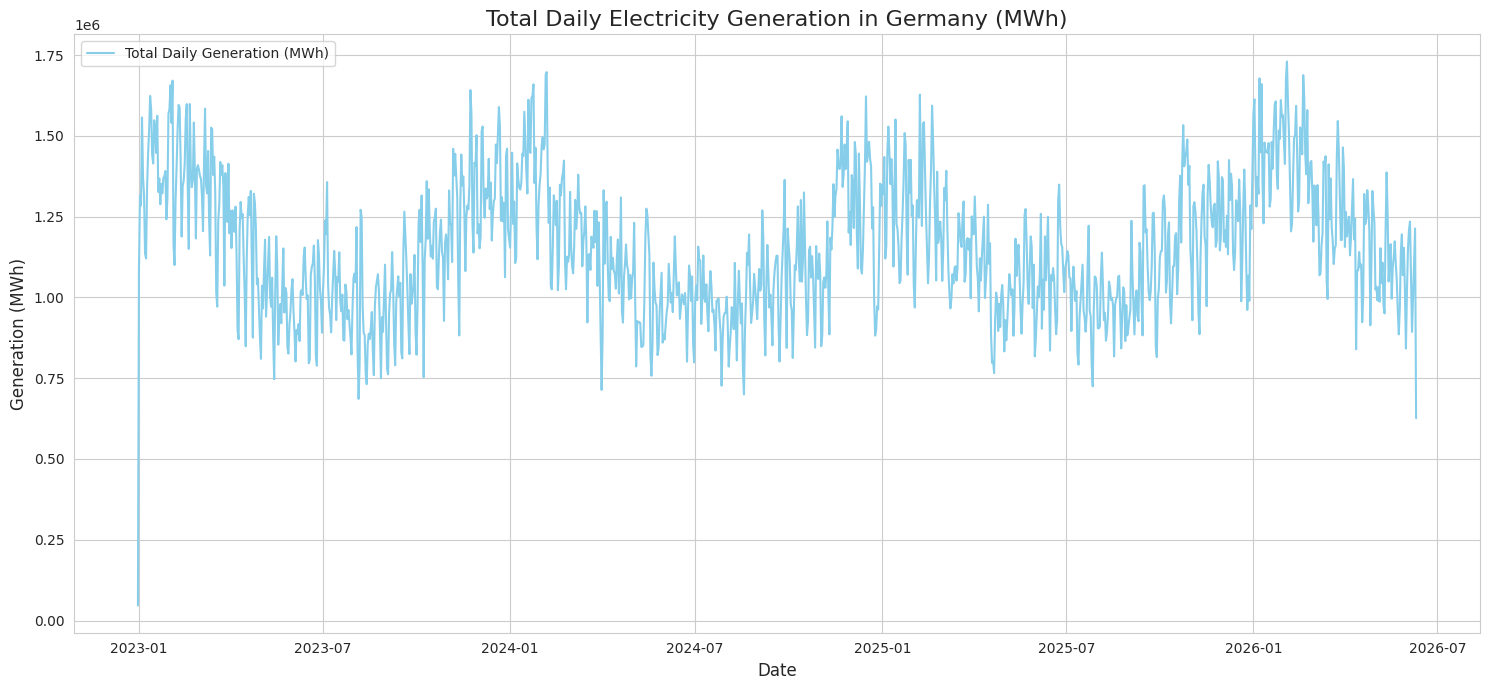


[대시보드용 딕셔너리 데이터 샘플 (최근 2일)]
[
    {
        "timestamp": "2026-06-09",
        "Wind onshore": 401477.125,
        "Fossil brown coal / lignite": 140640.0,
        "Solar": 279355.225,
        "Fossil gas": 75485.4,
        "Biomass": 93778.225,
        "Fossil hard coal": 42891.15,
        "Wind offshore": 102003.15,
        "Hydro Run-of-River": 50312.225,
        "Total": 1213737.35
    },
    {
        "timestamp": "2026-06-10",
        "Wind onshore": 119101.675,
        "Fossil brown coal / lignite": 79511.375,
        "Solar": 205293.1,
        "Fossil gas": 47837.2,
        "Biomass": 48770.75,
        "Fossil hard coal": 26173.525,
        "Wind offshore": 57378.975,
        "Hydro Run-of-River": 28278.375,
        "Total": 626367.325
    }
]


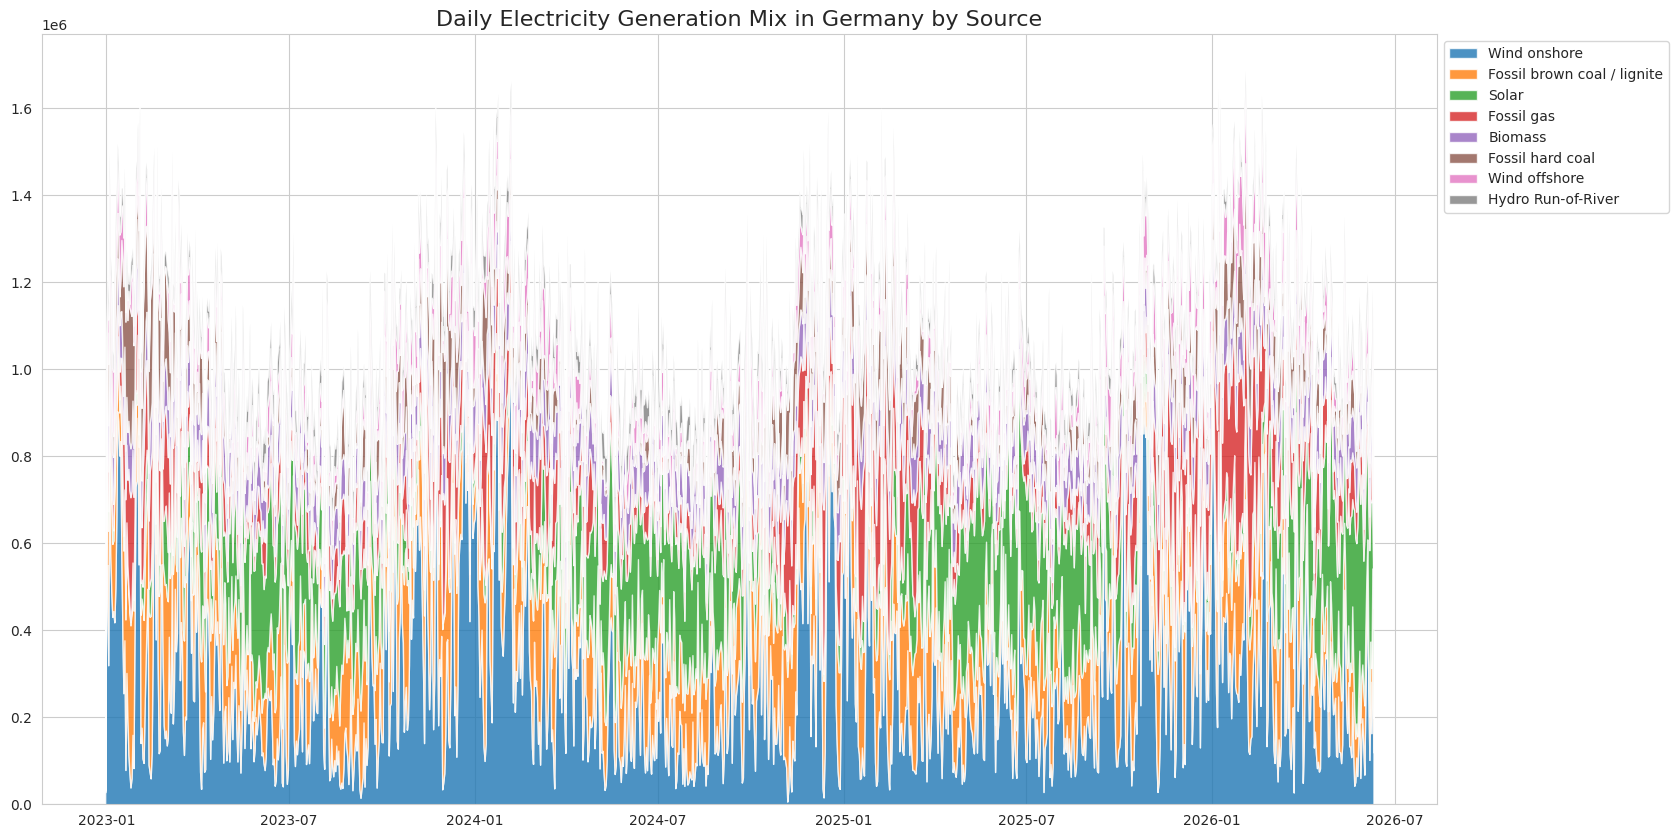

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Set plot style
sns.set_style("whitegrid")

# 1. Total Daily Electricity Generation (MWh)
plt.figure(figsize=(15, 7))
plt.plot(df_daily['Total'].index, df_daily['Total'].values, label='Total Daily Generation (MWh)', color='skyblue')
plt.title('Total Daily Electricity Generation in Germany (MWh)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Generation (MWh)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Daily Generation Mix (Stacked Area Plot)
# 'Total'은 그래프에 포함하지 않기 위해 제외합니다.
df_daily_plot = df_daily.drop(columns=['Total', 'Total_Calc'], errors='ignore')

# Select top sources
sources_mean = df_daily_plot.mean().sort_values(ascending=False)
top_sources = sources_mean.head(8).index.tolist()
existing_top_sources = [col for col in top_sources if col in df_daily_plot.columns]
df_daily_mix = df_daily_plot[existing_top_sources]

# --- 대시보드용 딕셔너리 생성 로직 (Total 포함) ---
# 시각화용 믹스 데이터에 'Total' 컬럼을 다시 합쳐서 딕셔너리를 만듭니다.
dashboard_df = df_daily_mix.copy()
dashboard_df['Total'] = df_daily['Total']
dashboard_df = dashboard_df.reset_index()
dashboard_df['timestamp'] = dashboard_df['timestamp'].dt.strftime('%Y-%m-%d')

# 딕셔너리 리스트로 변환
mix_data_list = dashboard_df.to_dict(orient='records')

# 샘플 출력 (Total_Calc 대신 Total이 나옵니다)
print("\n[대시보드용 딕셔너리 데이터 샘플 (최근 2일)]")
print(json.dumps(mix_data_list[-2:], indent=4, ensure_ascii=False))

# 실제 그래프 출력
plt.figure(figsize=(18, 10))
plt.stackplot(df_daily_mix.index, df_daily_mix.values.T, labels=df_daily_mix.columns, alpha=0.8)
plt.title('Daily Electricity Generation Mix in Germany by Source', fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [71]:
import pandas as pd

# 1. 태양광(Solar), 풍력(Wind Onshore/Offshore) 비중 계산

# 비중 계산
df_daily['Solar_Share'] = df_daily['Solar'] / df_daily['Total']
df_daily['Wind_Onshore_Share'] = df_daily['Wind onshore'] / df_daily['Total']
df_daily['Wind_Offshore_Share'] = df_daily['Wind offshore'] / df_daily['Total']

# 2. 신재생 에너지 전체 비율 계산
renewable_cols = [
    'Hydro Run-of-River', 'Biomass', 'Geothermal',
    'Hydro water reservoir', 'Wind offshore', 'Wind onshore', 'Solar'
]

available_renewables = [col for col in renewable_cols if col in df_daily.columns]
df_daily['Renewable_Total_Share'] = df_daily[available_renewables].sum(axis=1) / df_daily['Total']


# 결과 확인
display_cols = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share', 'Renewable_Share_of_Generation']
display(df_daily[display_cols].head())

print("\n[통계 요약]")
display(df_daily[display_cols].describe())

,Solar_Share,Wind_Onshore_Share,Wind_Offshore_Share,Renewable_Total_Share,Renewable_Share_of_Generation
timestamp,,,,,
2022-12-31,0.000000,0.589470,0.065946,0.778813,18.937500
2023-01-01,0.039736,0.483545,0.100164,0.752497,18.591146
2023-01-02,0.025243,0.417914,0.066169,0.619167,15.692708
2023-01-03,0.034904,0.248837,0.079880,0.479937,12.342969
2023-01-04,0.008433,0.590089,0.079544,0.772784,18.937240



[통계 요약]


,Solar_Share,Wind_Onshore_Share,Wind_Offshore_Share,Renewable_Total_Share,Renewable_Share_of_Generation
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,0.164812,0.248814,0.059445,0.609767,14.968923
std,0.118318,0.143944,0.030755,0.149473,3.531566
min,0.000000,0.006160,0.000161,0.196660,5.188021
25%,0.052493,0.129782,0.034288,0.515786,12.729883
50%,0.150179,0.225844,0.059054,0.624046,15.236458
75%,0.256662,0.343699,0.082414,0.728577,17.735091
max,0.496249,0.656520,0.142660,0.906694,22.316146


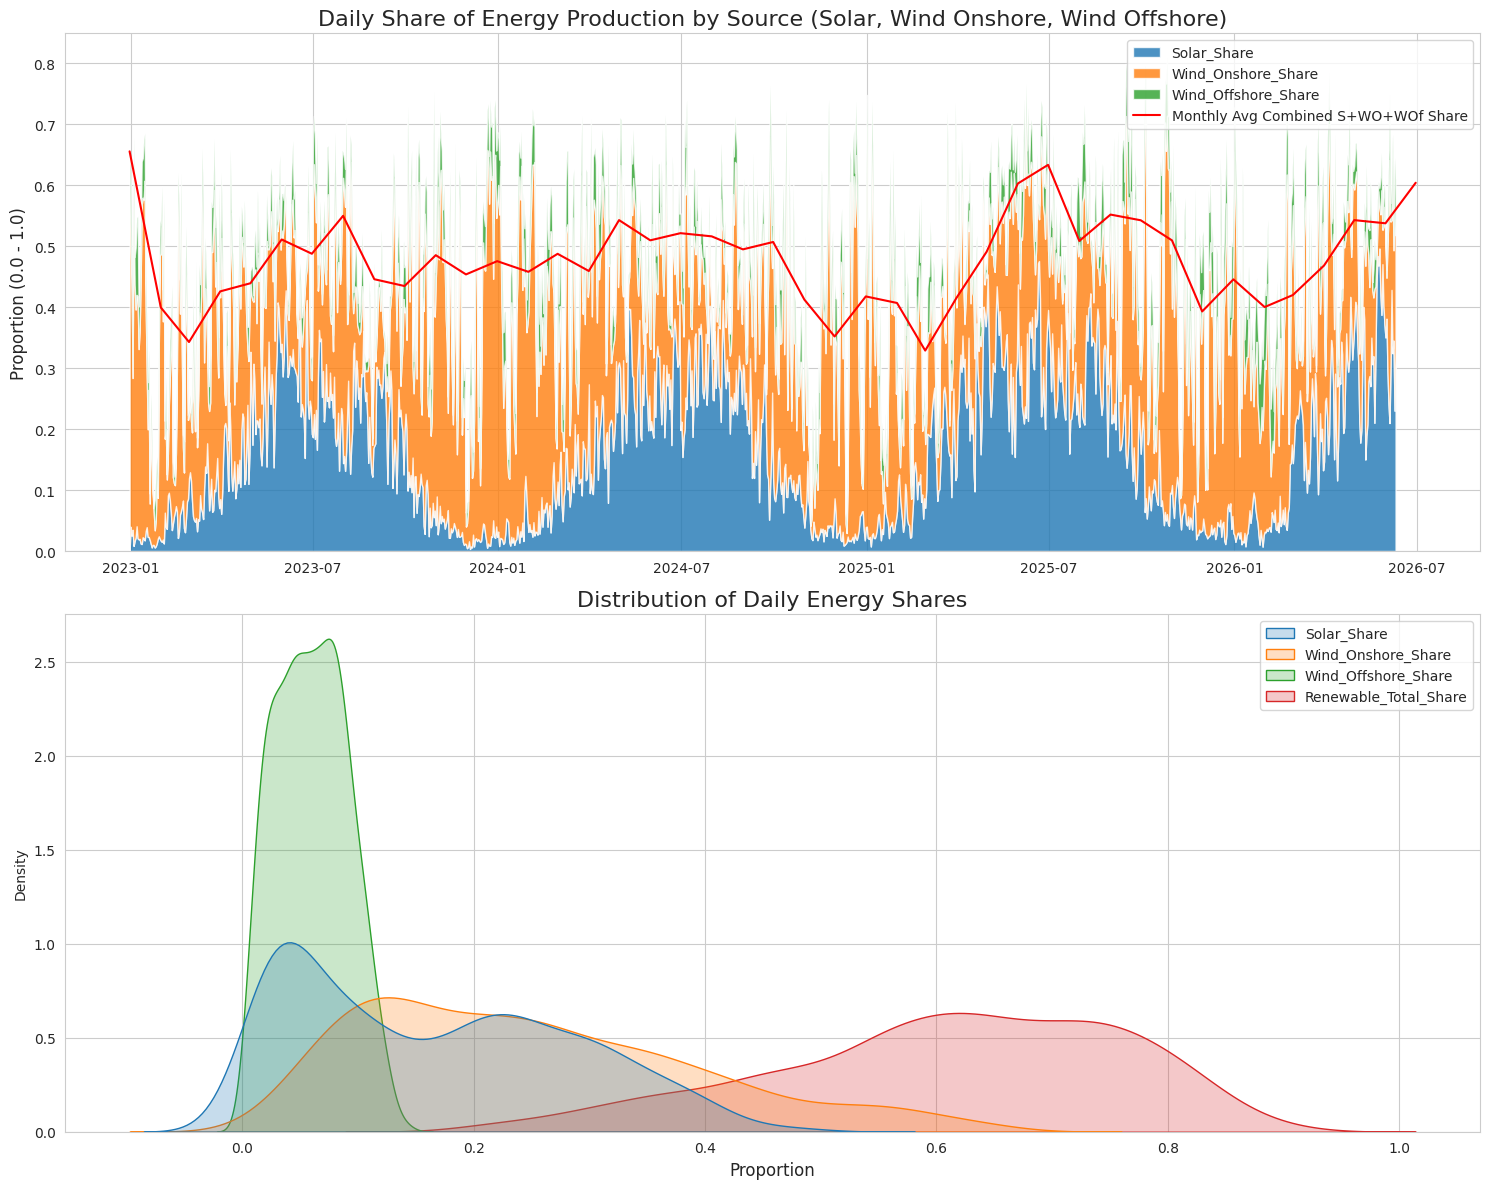

### [Key Insights from Energy Share Analysis] ###
1. 평균 신재생 에너지 비중: 전체 발전량 중 신재생 에너지가 차지하는 평균 비중은 약 61.0%로, 에너지 전환이 상당히 진행되었음을 보여줍니다.
2. 풍력 vs 태양광: 풍력(Onshore+Offshore)의 평균 비중(30.8%)이 태양광(16.5%)보다 높게 나타나며, 독일 에너지 생산의 핵심적인 역할을 하고 있습니다.
3. 변동성 리스크: 신재생 에너지 비중의 표준편차가 0.15로 나타나며, 기상 조건에 따라 하루 발전 비중이 급격히 변동하는 '간헐성' 문제가 시각적으로 확인됩니다.
4. 최대 공급 능력: 특정 일자에는 신재생 에너지 비중이 최대 90.7%까지 상승하며, 화석 연료 없이도 국가 전력 수요의 상당 부분을 충당할 수 있는 잠재력을 보여줍니다.


In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Ensure share columns are calculated before plotting ---
# 1. 태양광(Solar), 풍력(Wind Onshore/Offshore) 비중 계산


# 비중 계산
df_daily['Solar_Share'] = df_daily['Solar'] / df_daily['Total']
df_daily['Wind_Onshore_Share'] = df_daily['Wind onshore'] / df_daily['Total']
df_daily['Wind_Offshore_Share'] = df_daily['Wind offshore'] / df_daily['Total']

# 2. 신재생 에너지 전체 비율 계산
renewable_cols = [
    'Hydro Run-of-River', 'Biomass', 'Geothermal',
    'Hydro water reservoir', 'Wind offshore', 'Wind onshore', 'Solar'
]
available_renewables = [col for col in renewable_cols if col in df_daily.columns]
df_daily['Renewable_Total_Share'] = df_daily[available_renewables].sum(axis=1) / df_daily['Total']
# --- End of share columns calculation ---


# Set visualization style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# 1. Trend of Energy Shares over Time (Stacked Area Plot for individual shares)
share_cols = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share']
plt.sca(axes[0]) # Set current axes to the first subplot
plt.stackplot(df_daily.index, df_daily[share_cols].values.T, labels=share_cols, alpha=0.8)

# Calculate and add a line plot for the monthly average of the sum of the three shares
df_daily['Combined_SWO_Share'] = df_daily['Solar_Share'] + df_daily['Wind_Onshore_Share'] + df_daily['Wind_Offshore_Share']
df_monthly_avg_combined = df_daily['Combined_SWO_Share'].resample('ME').mean()
axes[0].plot(df_monthly_avg_combined.index, df_monthly_avg_combined, color='red', linestyle='-', label='Monthly Avg Combined S+WO+WOf Share')

axes[0].set_title('Daily Share of Energy Production by Source (Solar, Wind Onshore, Wind Offshore)', fontsize=16)
axes[0].set_ylabel('Proportion (0.0 - 1.0)', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(True)

# 2. Distribution of Renewable Shares (including Wind_Offshore_Share) - remains unchanged
sns.kdeplot(data=df_daily[['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share']], fill=True, ax=axes[1])
axes[1].set_title('Distribution of Daily Energy Shares', fontsize=16)
axes[1].set_xlabel('Proportion', fontsize=12)

plt.tight_layout()
plt.show()

# --- Insight Extraction ---
print("### [Key Insights from Energy Share Analysis] ###")

# 1. Renewable Dominance
avg_renewable = df_daily['Renewable_Total_Share'].mean() * 100
print(f"1. 평균 신재생 에너지 비중: 전체 발전량 중 신재생 에너지가 차지하는 평균 비중은 약 {avg_renewable:.1f}%로, 에너지 전환이 상당히 진행되었음을 보여줍니다.")

# 2. Wind vs Solar
wind_total_avg = (df_daily['Wind_Onshore_Share'].mean() + df_daily['Wind_Offshore_Share'].mean()) * 100
solar_avg = df_daily['Solar_Share'].mean() * 100
print(f"2. 풍력 vs 태양광: 풍력(Onshore+Offshore)의 평균 비중({wind_total_avg:.1f}%)이 태양광({solar_avg:.1f}%)보다 높게 나타나며, 독일 에너지 생산의 핵심적인 역할을 하고 있습니다.")

# 3. Variability & Volatility
renewable_std = df_daily['Renewable_Total_Share'].std()
print(f"3. 변동성 리스크: 신재생 에너지 비중의 표준편차가 {renewable_std:.2f}로 나타나며, 기상 조건에 따라 하루 발전 비중이 급격히 변동하는 '간헐성' 문제가 시각적으로 확인됩니다.")

# 4. Seasonal/Daily Peaks
max_renewable = df_daily['Renewable_Total_Share'].max() * 100
print(f"4. 최대 공급 능력: 특정 일자에는 신재생 에너지 비중이 최대 {max_renewable:.1f}%까지 상승하며, 화석 연료 없이도 국가 전력 수요의 상당 부분을 충당할 수 있는 잠재력을 보여줍니다.")

## 데이터 json 딕셔너리 형태로 저장

In [80]:
import json

# 1. 시각화 데이터 준비 (df_daily에서 Total 포함 상위 8개 소스 선택)
sources_mean = df_daily.drop(columns=['Total_Calc'], errors='ignore').mean().sort_values(ascending=False)
top_sources = sources_mean.head(8).index.tolist()

# 2. 딕셔너리 형태로 변환
# 인덱스인 timestamp를 컬럼으로 빼고 문자열로 변환합니다.
dashboard_mix_data = df_daily[top_sources].reset_index()
dashboard_mix_data['timestamp'] = dashboard_mix_data['timestamp'].dt.strftime('%Y-%m-%d')

# 리스트 내 딕셔너리 형태로 변환 (orient='records')
mix_data_list = dashboard_mix_data.to_dict(orient='records')

# 3. 데이터 구조 확인을 위해 마지막 2일치 데이터 출력
print("--- Dashboard Data Dictionary (Generation Mix) ---")
# Total_Calc 대신 Total이 포함된 것을 확인할 수 있습니다.
print(json.dumps(mix_data_list[-2:], indent=4, ensure_ascii=False))

# 4. 전체 데이터 개수 확인
print(f"\n총 {len(mix_data_list)}일치의 데이터가 딕셔너리로 생성되었습니다.")

--- Dashboard Data Dictionary (Generation Mix) ---
[
    {
        "timestamp": "2026-06-09",
        "Total": 1213737.35,
        "Wind onshore": 401477.125,
        "Fossil brown coal / lignite": 140640.0,
        "Solar": 279355.225,
        "Fossil gas": 75485.4,
        "Biomass": 93778.225,
        "Fossil hard coal": 42891.15,
        "Wind offshore": 102003.15
    },
    {
        "timestamp": "2026-06-10",
        "Total": 626367.325,
        "Wind onshore": 119101.675,
        "Fossil brown coal / lignite": 79511.375,
        "Solar": 205293.1,
        "Fossil gas": 47837.2,
        "Biomass": 48770.75,
        "Fossil hard coal": 26173.525,
        "Wind offshore": 57378.975
    }
]

총 1258일치의 데이터가 딕셔너리로 생성되었습니다.


In [81]:
import json

# 1. 일간 발전 믹스 데이터 (Top Sources + Total)
df_mix_dict = df_daily[existing_top_sources + ['Total']].reset_index()
df_mix_dict['timestamp'] = df_mix_dict['timestamp'].dt.strftime('%Y-%m-%d')
generation_mix_data = df_mix_dict.to_dict(orient='records')

# 2. 신재생 에너지 비중 데이터 (Shares + Combined)
share_cols = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Renewable_Total_Share', 'Combined_SWO_Share']
df_share_dict = df_daily[share_cols].reset_index()
df_share_dict['timestamp'] = df_share_dict['timestamp'].dt.strftime('%Y-%m-%d')
energy_share_data = df_share_dict.to_dict(orient='records')

# 결과 확인 (샘플 출력)
print("=== 1. 발전 믹스 데이터 샘플 (최근 1일) ===")
print(json.dumps(generation_mix_data[-1:], indent=4, ensure_ascii=False))

print("\n=== 2. 신재생 비중 데이터 샘플 (최근 1일) ===")
print(json.dumps(energy_share_data[-1:], indent=4, ensure_ascii=False))

=== 1. 발전 믹스 데이터 샘플 (최근 1일) ===
[
    {
        "timestamp": "2026-06-10",
        "Wind onshore": 119101.675,
        "Fossil brown coal / lignite": 79511.375,
        "Solar": 205293.1,
        "Fossil gas": 47837.2,
        "Biomass": 48770.75,
        "Fossil hard coal": 26173.525,
        "Wind offshore": 57378.975,
        "Hydro Run-of-River": 28278.375,
        "Total": 626367.325
    }
]

=== 2. 신재생 비중 데이터 샘플 (최근 1일) ===
[
    {
        "timestamp": "2026-06-10",
        "Solar_Share": 0.3277519305465048,
        "Wind_Onshore_Share": 0.19014669227836878,
        "Wind_Offshore_Share": 0.09160595182706889,
        "Renewable_Total_Share": 0.7360143666497929,
        "Combined_SWO_Share": 0.6095045746519425
    }
]


In [74]:
from github import Github
import json
from google.colab import userdata

# GitHub 설정
try:
    token = userdata.get('GITHUB_TOKEN')
    g = Github(token)
    repo = g.get_repo("Giraffe-Shin/trading")

    # 파일 가져오기
    file_path = "dashboard_data.json"
    contents = repo.get_contents(file_path, ref="main")
    data = json.loads(contents.decoded_content.decode())

    # 구조 요약 출력
    print(f"--- {file_path} 구조 분석 ---")
    print(f"최상위 키 목록: {list(data.keys())}\n")

    # 각 키별 샘플 데이터 확인
    for key in data.keys():
        if isinstance(data[key], list):
            print(f"[{key}]: 리스트 형태 (총 {len(data[key])}개 항목)")
            if len(data[key]) > 0:
                print(f"  샘플: {data[key][0]}")
        elif isinstance(data[key], dict):
            print(f"[{key}]: 딕셔너리 형태")
            print(f"  내부 키: {list(data[key].keys())}")
            print(f"  데이터: {data[key]}")
        else:
            print(f"[{key}]: {data[key]}")
        print("-" * 30)

except Exception as e:
    print(f"파일을 불러오는 중 오류가 발생했습니다: {e}")

/tmp/ipykernel_2006/1416612125.py:8: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g = Github(token)


--- dashboard_data.json 구조 분석 ---
최상위 키 목록: ['time_series', 'importance', 'load_monthly_error', 'renewable_monthly_mae', 'metrics', 'insights', 'ft_time_series', 'model_comparison', 'analysis_results']

[time_series]: 리스트 형태 (총 100개 항목)
  샘플: {'date': '69884', 'actual': 10.51, 'predicted': 37.17461013793945}
------------------------------
[importance]: 리스트 형태 (총 7개 항목)
  샘플: {'feature': 'solar_mw', 'importance': 0.3208904564380646}
------------------------------
[load_monthly_error]: 리스트 형태 (총 12개 항목)
  샘플: {'month': 1, 'error_rate': 4.31275449855661}
------------------------------
[renewable_monthly_mae]: 리스트 형태 (총 12개 항목)
  샘플: {'month': 1, 'solar_mae': 230.29827645051193, 'wind_on_mae': 1725.1141126279863, 'wind_off_mae': 663.8115529010239}
------------------------------
[metrics]: 딕셔너리 형태
  내부 키: ['mae']
  데이터: {'mae': 19.700196023815213}
------------------------------
[insights]: 딕셔너리 형태
  내부 키: ['time_series', 'importance', 'load_error']
  데이터: {'time_series': '최적화된 XGBoost 모델을 통

In [82]:
import json
import pandas as pd
import numpy as np

# --- 1. Preparation: Clean and Format Data ---
df_json = df_daily.reset_index()
df_json['timestamp'] = df_json['timestamp'].dt.strftime('%Y-%m-%d')

# --- 2. Generation Mix Data (English) ---
# Top 8 sources + Total for stack charts
generation_mix = df_json[['timestamp', 'Total'] + existing_top_sources].to_dict(orient='records')

# --- 3. Total Generation Only ---
total_generation = df_json[['timestamp', 'Total']].to_dict(orient='records')

# --- 4. Daily Share of Energy Production (Trends) ---
# Renaming for dashboard consistency
share_trend_cols = ['timestamp', 'Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share', 'Combined_SWO_Share']
daily_share_trends = df_json[share_trend_cols].to_dict(orient='records')

# --- 5. Distribution of Daily Energy Shares (KDE Data) ---
# For distribution plots, we provide raw series data or binned counts.
# Here we provide the raw series for D3.js to process distributions
distribution_data = {
    "solar": df_daily['Solar_Share'].dropna().tolist(),
    "wind_onshore": df_daily['Wind_Onshore_Share'].dropna().tolist(),
    "wind_offshore": df_daily['Wind_Offshore_Share'].dropna().tolist(),
    "renewable_total": df_daily['Renewable_Total_Share'].dropna().tolist()
}

# --- 6. Update GitHub JSON ---
try:
    from github import Github
    from google.colab import userdata

    token = userdata.get('GITHUB_TOKEN')
    g = Github(token)
    repo = g.get_repo("Giraffe-Shin/trading")
    file_path = "dashboard_data.json"
    contents = repo.get_contents(file_path, ref="main")
    data = json.loads(contents.decoded_content.decode())

    # Injecting standardized English data
    data['generation_mix'] = generation_mix
    data['total_generation_trend'] = total_generation
    data['daily_share_trends'] = daily_share_trends
    data['daily_share_distribution'] = distribution_data

    # English Analysis Insights
    data['analysis_results'] = {
        "summary": {
            "avg_renewable_share": round(float(avg_renewable), 2),
            "wind_total_avg": round(float(wind_total_avg), 2),
            "solar_avg": round(float(solar_avg), 2),
            "variability_std": round(float(renewable_std), 4)
        },
        "key_messages": [
            f"Average renewable share stands at {avg_renewable:.1f}% of total generation.",
            f"Wind (Onshore + Offshore) contributes {wind_total_avg:.1f}%, leading the energy transition.",
            f"Solar energy provides an average of {solar_avg:.1f}% with high seasonal peaks.",
            f"System flexibility is crucial due to a volatility index (std) of {renewable_std:.2f}."
        ],
        "last_updated": pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    # Push to GitHub
    updated_json = json.dumps(data, indent=4, ensure_ascii=False)
    repo.update_file(
        path=contents.path,
        message="Update dashboard with English standardized data and distribution stats",
        content=updated_json,
        sha=contents.sha,
        branch="main"
    )
    print("Successfully updated dashboard_data.json with all English datasets.")

except Exception as e:
    print(f"Error during GitHub update: {e}")

/tmp/ipykernel_2006/610315825.py:37: DeprecationWarning: Argument login_or_token is deprecated, please use auth=github.Auth.Token(...) instead
  g = Github(token)


Successfully updated dashboard_data.json with all English datasets.


In [90]:
from github import Github, Auth
from google.colab import userdata
import re

try:
    token = userdata.get('GITHUB_TOKEN')
    auth = Auth.Token(token)
    g = Github(auth=auth)
    repo = g.get_repo("Giraffe-Shin/trading")
    contents = repo.get_contents("index.html", ref="main")
    raw_html = contents.decoded_content.decode('utf-8')

    # 1. Cleaning logic remains the same to avoid duplicates
    clean_html = re.sub(r'<div class="chart-grid-section">.*?</div>\s*</script>\s*</div>', '', raw_html, flags=re.DOTALL)

    # 2. Updated D3 Logic with Legend and remaining charts
    new_layout = """
        <div class="chart-grid-section">
            <style>
                .chart-grid { display: grid; grid-template-columns: repeat(auto-fit, minmax(450px, 1fr)); gap: 20px; margin-top: 20px; }
                .chart-card { background: white; padding: 20px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }
                .chart-card h3 { text-align: center; margin-bottom: 15px; color: #2c3e50; font-size: 1.1em; }
                .legend { display: flex; flex-wrap: wrap; justify-content: center; gap: 10px; margin-top: 10px; font-size: 12px; }
                .legend-item { display: flex; align-items: center; gap: 4px; }
                .legend-color { width: 12px; height: 12px; border-radius: 2px; }
                svg { width: 100%; height: auto; font-family: sans-serif; }
            </style>
            <div class="chart-grid">
                <div class="chart-card"><h3>Generation Mix (Daily)</h3><div id="mix-chart"></div><div id="mix-legend" class="legend"></div></div>
                <div class="chart-card"><h3>Total Generation Trend</h3><div id="total-chart"></div></div>
                <div class="chart-card"><h3>Renewable Share Trends</h3><div id="share-chart"></div></div>
                <div class="chart-card"><h3>Daily Share Distribution (KDE)</h3><div id="dist-chart"></div></div>
            </div>
            <script src="https://d3js.org/d3.v7.min.js"></script>
            <script>
                (function() {
                    const url = "https://raw.githubusercontent.com/Giraffe-Shin/trading/main/dashboard_data.json";
                    const m = {t: 20, r: 30, b: 40, l: 50}, w = 500 - m.l - m.r, h = 300 - m.t - m.b;
                    const colors = d3.scaleOrdinal(d3.schemeTableau10);

                    d3.json(url).then(data => {
                        if (data.generation_mix) drawMix(data.generation_mix);
                        if (data.total_generation_trend) drawTotal(data.total_generation_trend);
                        if (data.daily_share_trends) drawShareTrends(data.daily_share_trends);
                        if (data.daily_share_distribution) drawDist(data.daily_share_distribution);
                    });

                    function drawMix(data) {
                        const svg = d3.select("#mix-chart").append("svg").attr("viewBox", `0 0 500 300`)
                            .append("g").attr("transform", `translate(${m.l},${m.t})`);
                        const x = d3.scaleTime().domain(d3.extent(data, d => new Date(d.timestamp))).range([0, w]);
                        const y = d3.scaleLinear().domain([0, d3.max(data, d => d.Total)]).range([h, 0]);
                        svg.append("g").attr("transform", `translate(0,${h})`).call(d3.axisBottom(x).ticks(5));
                        svg.append("g").call(d3.axisLeft(y).ticks(5).tickFormat(d3.format(".2s")));

                        const keys = Object.keys(data[0]).filter(k => k !== 'timestamp' && k !== 'Total');
                        const stacked = d3.stack().keys(keys)(data);

                        svg.selectAll("path").data(stacked).join("path")
                            .attr("fill", d => colors(d.key))
                            .attr("d", d3.area().x(d => x(new Date(d.data.timestamp))).y0(d => y(d[0])).y1(d => y(d[1])));

                        const legend = d3.select("#mix-legend");
                        keys.forEach(key => {
                            const item = legend.append("div").attr("class", "legend-item");
                            item.append("div").attr("class", "legend-color").style("background", colors(key));
                            item.append("span").text(key);
                        });
                    }

                    function drawTotal(data) {
                        const svg = d3.select("#total-chart").append("svg").attr("viewBox", `0 0 500 300`)
                            .append("g").attr("transform", `translate(${m.l},${m.t})`);
                        const x = d3.scaleTime().domain(d3.extent(data, d => new Date(d.timestamp))).range([0, w]);
                        const y = d3.scaleLinear().domain([0, d3.max(data, d => d.Total)]).range([h, 0]);
                        svg.append("g").attr("transform", `translate(0,${h})`).call(d3.axisBottom(x).ticks(5));
                        svg.append("g").call(d3.axisLeft(y).ticks(5));
                        svg.append("path").datum(data).attr("fill", "none").attr("stroke", "#3498db").attr("stroke-width", 2)
                            .attr("d", d3.line().x(d => x(new Date(d.timestamp))).y(d => y(d.Total)));
                    }

                    function drawShareTrends(data) {
                        const svg = d3.select("#share-chart").append("svg").attr("viewBox", `0 0 500 300`)
                            .append("g").attr("transform", `translate(${m.l},${m.t})`);
                        const x = d3.scaleTime().domain(d3.extent(data, d => new Date(d.timestamp))).range([0, w]);
                        const y = d3.scaleLinear().domain([0, 1]).range([h, 0]);
                        svg.append("g").attr("transform", `translate(0,${h})`).call(d3.axisBottom(x).ticks(5));
                        svg.append("g").call(d3.axisLeft(y).ticks(5).tickFormat(d3.format(".0%")));

                        const lines = ['Solar_Share', 'Wind_Onshore_Share', 'Wind_Offshore_Share'];
                        lines.forEach((key, i) => {
                            svg.append("path").datum(data).attr("fill", "none").attr("stroke", colors(i)).attr("stroke-width", 1.5)
                                .attr("d", d3.line().x(d => x(new Date(d.timestamp))).y(d => y(d[key] || 0)));
                        });
                    }

                    function drawDist(data) {
                        const svg = d3.select("#dist-chart").append("svg").attr("viewBox", `0 0 500 300`)
                            .append("g").attr("transform", `translate(${m.l},${m.t})`);
                        const x = d3.scaleLinear().domain([0, 1]).range([0, w]);
                        svg.append("g").attr("transform", `translate(0,${h})`).call(d3.axisBottom(x).ticks(5).tickFormat(d3.format(".0%")));

                        function kde(kernel, thresholds, data) {
                            return thresholds.map(t => [t, d3.mean(data, d => kernel(t - d))]);
                        }
                        function epanechnikov(bandwidth) {
                            return x => Math.abs(x /= bandwidth) <= 1 ? 0.75 * (1 - x * x) / bandwidth : 0;
                        }

                        const thresholds = x.ticks(40);
                        const density = kde(epanechnikov(0.05), thresholds, data.renewable_total);
                        const y = d3.scaleLinear().domain([0, d3.max(density, d => d[1])]).range([h, 0]);

                        svg.append("path").datum(density).attr("fill", "#1abc9c").attr("fill-opacity", 0.3).attr("stroke", "#16a085")
                            .attr("stroke-width", 2).attr("d", d3.area().x(d => x(d[0])).y0(h).y1(d => y(d[1])));
                    }
                })();
            </script>
        </div>
    """

    if "<div id='page1'" in clean_html:
        final_html = clean_html.replace("<div id='page1' class='page active'>", f"<div id='page1' class='page active'>\n{new_layout}")
    else:
        final_html = clean_html

    repo.update_file(
        path="index.html",
        message="Feat: Complete D3 visualizations with legend and KDE distribution",
        content=final_html,
        sha=contents.sha,
        branch="main"
    )
    print("D3.js visualizations and legend successfully updated.")
except Exception as e:
    print(f"Error: {e}")

D3.js visualizations and legend successfully updated.


In [91]:
from github import Github, Auth
from google.colab import userdata

try:
    # 1. GitHub 접근 설정
    token = userdata.get('GITHUB_TOKEN')
    auth = Auth.Token(token)
    g = Github(auth=auth)
    repo = g.get_repo("Giraffe-Shin/trading")

    # 2. index.html 파일 가져오기
    file_path = "index.html"
    contents = repo.get_contents(file_path, ref="main")
    html_content = contents.decoded_content.decode('utf-8')

    # 3. 구조 분석을 위한 주요 태그 추출
    print(f"--- {file_path} 구조 분석 결과 ---")

    # 탭 컨텐츠(페이지) 구분 확인
    import re
    tabs = re.findall(r'<div id=\"(.*?)\" class=\"tab-content\">', html_content)
    print(f"발견된 탭 ID 목록: {tabs}")

    # 전체 내용 출력 (구조 파악용)
    print("\n[파일 전체 내용]")
    print("="*50)
    print(html_content)
    print("="*50)

except Exception as e:
    print(f"파일 로드 중 오류 발생: {e}")

--- index.html 구조 분석 결과 ---
발견된 탭 ID 목록: []

[파일 전체 내용]
<!DOCTYPE html>
<html>
<head>
    <meta charset='utf-8'>
    <title>Advanced Energy Market Dashboard</title>
    <script src='https://cdn.jsdelivr.net/npm/chart.js'></script>
    <style>
        body { font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; background-color: #f0f2f5; }
        .nav-tabs { display: flex; background: #2c3e50; padding: 10px 20px; gap: 10px; }
        .tab-button { color: white; border: none; background: none; padding: 10px 20px; cursor: pointer; border-radius: 4px; }
        .tab-button.active { background: #34495e; font-weight: bold; border-bottom: 3px solid #3498db; }
        .content { padding: 30px; max-width: 1200px; margin: auto; }
        .page { display: none; }
        .page.active { display: block; }
        .card { background: white; padding: 25px; border-radius: 12px; box-shadow: 0 4px 6px rgba(0,0,0,0.1); margin-bottom: 30px; }
        .insight { background: #f8f9fa; bor